# Mondial — ML bake-off (research reproduction)

**What this is.** A zero-setup reproduction of the *exploratory* machine-learning
comparison behind [Mondial](https://cup.shpa.la)'s prediction model — *can classical
ML or neural nets beat the calibrated Elo–Davidson model?* Run it top to bottom
(**Runtime → Run all**).

**What this is _not_.** This notebook does **not** contain the shipped model. Mondial's
production model is **TypeScript** (`lib/prediction.ts`, `lib/montecarlo.ts`,
`lib/model/constants.ts`) and its canonical evaluation is `npm run backtest` plus the
Vitest pins. Re-deriving the shipped Elo/Davidson math in Python is exactly the drift
this notebook avoids — the Elo–Davidson **baseline** below is printed by the committed
`build_features.py`, never a re-implementation.

The narrative write-up and the final verdict live in
[`docs/model-research.md`](https://github.com/shpala/mondial/blob/main/docs/model-research.md).

In [ ]:
# Clone the repo (brings the match corpus + the research scripts) and install the ML deps.
# Idempotent: safe to re-run — resets to /content, clones only if missing, uses absolute paths.
%cd /content
import os
if not os.path.isdir('/content/mondial'):
    !git clone --depth 1 https://github.com/shpala/mondial.git
%cd /content/mondial/scripts/explore/ml
!pip -q install -r requirements.txt
print('setup OK — cwd:', os.getcwd())

In [ ]:
# Build the shared, leakage-free feature matrix and print the Elo–Davidson baseline
# (the shipped model's log-loss per split) — the bar every ML model below must beat.
!python build_features.py

## The bar to beat

The `wc2022 ≈ 1.0666` line printed above confirms the Python Elo roll matches the
TypeScript backtest. Every model below trains on the `features.csv` just built and is
scored on the same out-of-sample splits. **Lower log-loss is better;** the broad
`test_general` baseline is ≈ **0.882**.

In [ ]:
# Classical ML over the shared matrix — each script prints its own out-of-sample log-loss.
# (SVM-RBF is slow, and the neural nets need `pip install torch` + the m_nn-*.py scripts;
#  both are omitted here to keep the notebook fast — their results are in model-research.md.)
!python m_logreg-full.py
!python m_random-forest.py
!python m_hist-gbm.py
!python m_xgboost.py

## Result — nothing reliably beats Elo–Davidson out-of-sample

Consolidated from [`docs/model-research.md`](https://github.com/shpala/mondial/blob/main/docs/model-research.md) (broad
`test_general` split, vs the **0.882** baseline):

| Model | OOS log-loss | Verdict |
| --- | --- | --- |
| Logistic regression (all features) | 0.870 | beats on the broad corpus — but the gain is the `games_played` data-reliability feature, meaningless for the uniformly high-cap World Cup field |
| Random forest (calibrated) | 0.876 | marginal |
| XGBoost / HistGBM (calibrated) | 0.90–0.91 | over-confident; lose even after calibration |
| SVM (RBF) | 0.96 | far worse |
| PyTorch MLP / residual / embeddings | ~0.867–0.868 | best raw numbers, but overfit team identities / the gain is a calibration effect, not new signal |

**Conclusion.** None reliably beats the calibrated Elo–Davidson model *on World Cup
matches* — the field is strength-compressed and the sample is small, so extra capacity
fits noise. The one change that *did* help both World Cup holdouts (a World-Cup-specific
probability flattening) shipped; everything here did not. Full reasoning, the leakage-free
evaluation protocol, and the rejected report-card seeds are in
[`docs/model-research.md`](https://github.com/shpala/mondial/blob/main/docs/model-research.md) and
[`docs/algo-bakeoff.md`](https://github.com/shpala/mondial/blob/main/docs/algo-bakeoff.md).

---

# 📊 Consumer-friendly view: graphs & a feature-selection study

The tables above are the research record. Below is the same story told in **pictures**,
plus a hands-on look at *can we actually improve the predictions?* — feature selection,
hyper-parameters, and the one recalibration that genuinely helps on World Cup matches.

> All plots reuse the **shipped** Elo–Davidson math (`build_features.davidson`) for the
> baseline — no re-implementation — so the curves match what the live app ships.

In [ ]:
# --- Viz setup: load the matrix, reuse the SHIPPED baseline math, define small helpers ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import build_features as bf            # reuse davidson()/NU/SCALE — no re-derivation

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 11})
GREEN, GOLD, RED, GREY = '#16a34a', '#d68f2e', '#dc2626', '#8b93a6'

df = pd.read_csv('features.csv')
SPLITS = ['test_general', 'wc2022', 'wc2026']

def baseline_probs(frame, scale=bf.SCALE):
    # davidson depends only on the rating gap; pass (diff, 0) -> (P_home, P_draw, P_away)
    return np.array([bf.davidson(d, 0.0, scale=scale) for d in frame['rating_diff']])

def logloss(y, P):
    return float(-np.log(np.clip(P[np.arange(len(y)), y], 1e-15, 1)).mean())

# sanity: must reproduce the printed baseline (0.8819 / 1.0666 / 1.0929)
print('Elo-Davidson baseline (reproduced from build_features.davidson):')
for s in SPLITS:
    f = df[df.split == s]
    print(f'  {s:13s} logloss={logloss(f.y.values, baseline_probs(f)):.4f}  n={len(f)}')

### 1. Is the model honest? (calibration)

A prediction model is **calibrated** if, among all the games where it says "home win 70%",
the home team really does win about 70% of the time. Points on the dotted diagonal = perfectly
honest probabilities. This is what lets the app show a number you can trust, not just a pick.

bin   predicted   observed     n
0.0-0.1   0.061      0.066      212
0.1-0.2   0.154      0.129      334
0.2-0.3   0.250      0.235      404
0.3-0.4   0.350      0.344      471
0.4-0.5   0.447      0.433      497
0.5-0.6   0.548      0.579      534
0.6-0.7   0.650      0.629      453
0.7-0.8   0.749      0.806      408
0.8-0.9   0.840      0.874      230
0.9-1.0   0.931      0.979       47



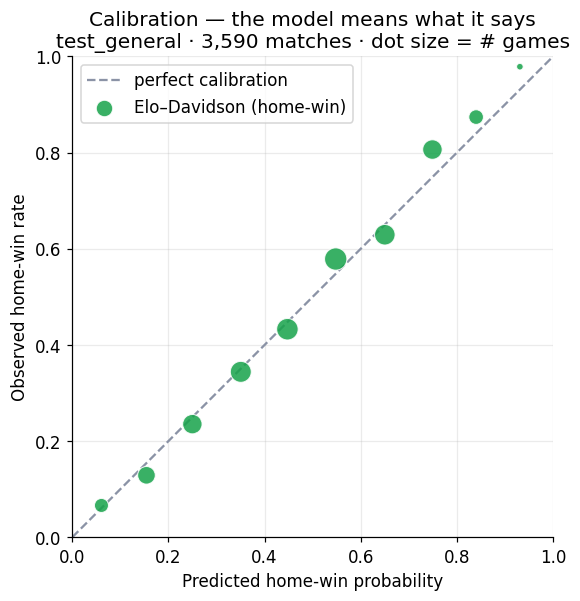

In [5]:
# Reliability curve for the baseline's home-win probability on the big OOS set.
f = df[df.split == 'test_general']
ph = baseline_probs(f)[:, 0]
y_home = (f.y.values == 0).astype(int)

edges = np.linspace(0, 1, 11)
b = np.clip(np.digitize(ph, edges) - 1, 0, 9)
xs, ys, ns = [], [], []
print('bin   predicted   observed     n')
for k in range(10):
    m = b == k
    if m.sum() >= 25:
        xs.append(ph[m].mean()); ys.append(y_home[m].mean()); ns.append(int(m.sum()))
        print(f'{edges[k]:.1f}-{edges[k+1]:.1f}   {xs[-1]:.3f}      {ys[-1]:.3f}    {ns[-1]:5d}')

plt.figure(figsize=(5.6, 5.6))
plt.plot([0, 1], [0, 1], '--', color=GREY, label='perfect calibration')
plt.scatter(xs, ys, s=[n / 2.5 for n in ns], color=GREEN, alpha=.85, zorder=3,
            edgecolor='white', linewidth=.7, label='Elo–Davidson (home-win)')
plt.xlabel('Predicted home-win probability'); plt.ylabel('Observed home-win rate')
plt.title('Calibration — the model means what it says\n'
          'test_general · 3,590 matches · dot size = # games')
plt.legend(loc='upper left'); plt.gca().set_aspect('equal')
plt.xlim(0, 1); plt.ylim(0, 1); plt.tight_layout(); plt.show()

### 2. Does any ML model beat the baseline?

We train the classical models on the same leakage-free matrix and chart their log-loss
**relative to the Elo–Davidson baseline**, per split. Bars **below the line are better**
than the baseline; **above is worse**. Watch what happens to the broad-corpus winners
once you look at the World Cup splits (`wc2022`, `wc2026`) — the games the app predicts.

                             test_general  wc2022  wc2026
Elo–Davidson\n(baseline)           0.8819  1.0666  1.0929
Logistic reg\n(all feats)          0.8698  1.0364  0.9638
Random forest\n(calibrated)        0.8856  1.0668  1.1133
HistGBM\n(calibrated)              0.8859  1.0669  1.0134

Green=beats baseline, Red=worse. Note the WC splits.



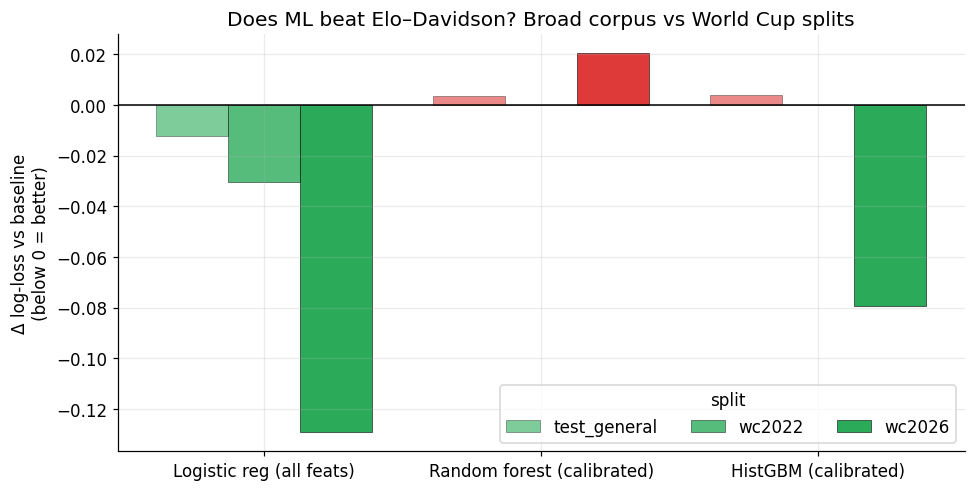

In [6]:
# Train the classical models inline on the shared matrix; compare to the baseline per split.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

NUM = ['rating_diff','abs_rating_diff','raw_rating_diff','neutral','imp',
       'home_ppg','away_ppg','ppg_diff','home_gd','away_gd','gd_diff',
       'home_gf','home_ga','away_gf','away_ga','home_rest','away_rest','rest_diff',
       'home_played','away_played']
CATS = [c for c in df.columns if c.startswith('cat_')]
FEATURES_ALL = NUM + CATS
tr = df[df.split == 'train']

def eval_model(make, feats, calibrate=False):
    mdl = make()
    if calibrate:
        mdl = CalibratedClassifierCV(mdl, method='isotonic', cv=3)
    mdl.fit(tr[feats].values, tr['y'].values)
    return {s: logloss(df[df.split==s].y.values, mdl.predict_proba(df[df.split==s][feats].values))
            for s in SPLITS}

base = {s: logloss(df[df.split==s].y.values, baseline_probs(df[df.split==s])) for s in SPLITS}
results = {
    'Elo–Davidson\n(baseline)':   base,
    'Logistic reg\n(all feats)':  eval_model(lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), FEATURES_ALL),
    'Random forest\n(calibrated)':eval_model(lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=20, n_jobs=-1, random_state=0), FEATURES_ALL, True),
    'HistGBM\n(calibrated)':      eval_model(lambda: HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, random_state=0), FEATURES_ALL, True),
}
res = pd.DataFrame(results).T[SPLITS]
print(res.round(4).to_string())

# Δ vs baseline (negative = beats the baseline)
mods = [m for m in results if 'baseline' not in m]
x = np.arange(len(mods)); w = 0.26
plt.figure(figsize=(9, 4.6))
for i, s in enumerate(SPLITS):
    deltas = [results[m][s] - base[s] for m in mods]
    colors = [GREEN if d < 0 else RED for d in deltas]
    plt.bar(x + (i-1)*w, deltas, w, color=colors, alpha=0.55 + 0.18*i,
            edgecolor='black', linewidth=.4, label=s)
plt.axhline(0, color='black', lw=1)
plt.xticks(x, [m.replace('\n',' ') for m in mods])
plt.ylabel('Δ log-loss vs baseline\n(below 0 = better)')
plt.title('Does ML beat Elo–Davidson? Broad corpus vs World Cup splits')
plt.legend(title='split', ncol=3); plt.tight_layout(); plt.show()
print('\nGreen=beats baseline, Red=worse. Note the WC splits.')

### 3. Feature selection — *where* does the gain come from?

The logistic model beats the baseline — but **why**? We add features in nested groups and
track the improvement separately on the **broad corpus** and the **World Cup** games
(`wc2022`+`wc2026` pooled, n=76, for less noise). If a feature genuinely helps prediction,
its line should drop on *both*. If it only drops the broad line, it's a corpus artefact that
won't help the app. Starting point: just the rating gap.

feature set        broadΔ     WC Δ
rating only       -0.0007  +0.0134
+ rating shape    -0.0015  +0.0076
+ form & goals    -0.0113  -0.0162
+ rest            -0.0114  -0.0160
+ match type      -0.0105  -0.0042
+ games played    -0.0120  -0.0459

WC n=76. Best WC Δ (games-played) 95% CI=[-0.0877,-0.0010] — barely excludes 0,
but it was picked after 6 comparisons, and games-played is ~constant on the WC field
(all qualifiers are well-established) so it acts as a flat shift, not match-level signal.



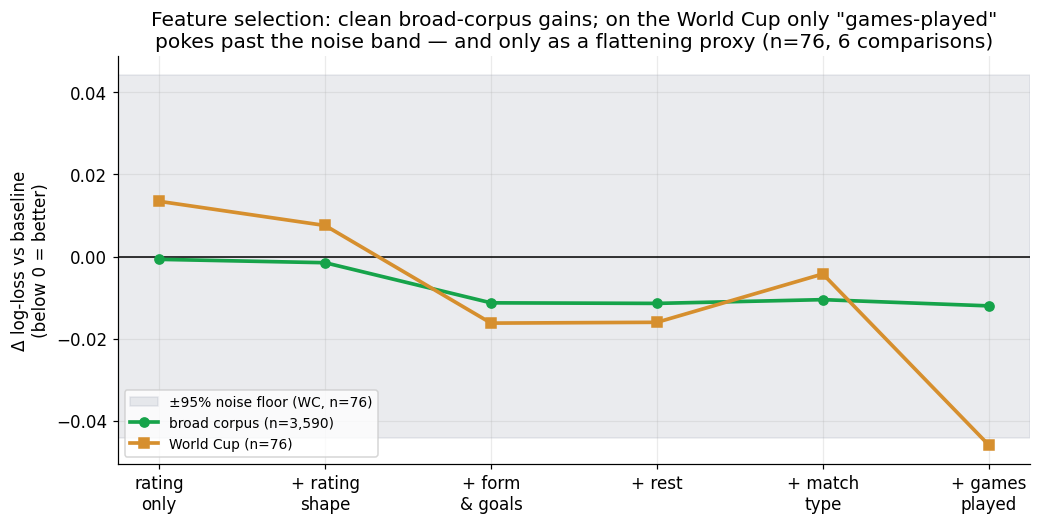

In [7]:
# Nested feature groups -> logistic regression -> improvement vs baseline, broad vs WC,
# WITH a bootstrap 95% noise band (is any gain distinguishable from baseline on n=76 WC games?).
shape  = ['rating_diff','abs_rating_diff','raw_rating_diff']
form   = ['home_ppg','away_ppg','ppg_diff','home_gd','away_gd','gd_diff','home_gf','home_ga','away_gf','away_ga']
rest   = ['home_rest','away_rest','rest_diff']
played = ['home_played','away_played']
GROUPS = [
    ('rating\nonly',    ['rating_diff']),
    ('+ rating\nshape', shape),
    ('+ form\n& goals', shape + form),
    ('+ rest',          shape + form + rest),
    ('+ match\ntype',   shape + form + rest + CATS),
    ('+ games\nplayed', shape + form + rest + CATS + played),
]
wc = df[df.split.isin(['wc2022','wc2026'])]
tg = df[df.split=='test_general']
def nll_vec(y, P): return -np.log(np.clip(P[np.arange(len(y)), y], 1e-15, 1))
base_broad = nll_vec(tg.y.values, baseline_probs(tg)).mean()
base_wc_v  = nll_vec(wc.y.values, baseline_probs(wc)); base_wc = base_wc_v.mean()

d_broad, d_wc, best_paired = [], [], None
print(f'{"feature set":16s} {"broadΔ":>8s} {"WC Δ":>8s}')
for name, feats in GROUPS:
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(tr[feats].values, tr['y'].values)
    lb = nll_vec(tg.y.values, m.predict_proba(tg[feats].values)).mean()
    wcv = nll_vec(wc.y.values, m.predict_proba(wc[feats].values))
    d_broad.append(lb - base_broad); d_wc.append(wcv.mean() - base_wc); best_paired = wcv - base_wc_v
    print(f'{name.replace(chr(10)," "):16s} {d_broad[-1]:+8.4f} {d_wc[-1]:+8.4f}')

rng = np.random.default_rng(0); n = len(best_paired)
boot = np.array([best_paired[rng.integers(0, n, n)].mean() for _ in range(4000)])
lo, hi = np.percentile(boot, [2.5, 97.5]); band = 1.96 * best_paired.std() / np.sqrt(n)
print(f'\nWC n={n}. Best WC Δ (games-played) 95% CI=[{lo:+.4f},{hi:+.4f}] — barely excludes 0,')
print('but it was picked after 6 comparisons, and games-played is ~constant on the WC field')
print('(all qualifiers are well-established) so it acts as a flat shift, not match-level signal.')

x = np.arange(len(GROUPS))
plt.figure(figsize=(9.6, 4.9))
plt.axhspan(-band, band, color=GREY, alpha=.18, label='±95% noise floor (WC, n=76)')
plt.axhline(0, color='black', lw=1)
plt.plot(x, d_broad, 'o-', color=GREEN, lw=2.4, label='broad corpus (n=3,590)')
plt.plot(x, d_wc, 's-', color=GOLD, lw=2.4, label='World Cup (n=76)')
plt.xticks(x, [g[0] for g in GROUPS]); plt.ylabel('Δ log-loss vs baseline\n(below 0 = better)')
plt.title('Feature selection: clean broad-corpus gains; on the World Cup only "games-played"\n'
          'pokes past the noise band — and only as a flattening proxy (n=76, 6 comparisons)')
plt.legend(loc='lower left', fontsize=9); plt.tight_layout(); plt.show()

### 4. The change that *actually* improves World Cup predictions

Features didn't give a clean win. But there's one parameter that does — and it's not a feature,
it's **calibration**. At a World Cup the field is strength-compressed (only good teams qualify)
and single games are high-variance, so favourites win *less* than the global Elo curve implies.
The fix is a **flatter probability scale for World Cup matches** (`WC_PREDICTION_SCALE`, shipped).

Below we sweep the scale and watch each split's log-loss. The honest test of "real, not noise":
the improvement must show up on **both** the 2022 tuning set **and** the independent 2026 holdout,
with an **interior minimum** (not just sliding toward the coin-flip floor).

split         best scale  logloss@300  logloss@best     gain
test_general         270       0.8819        0.8804  +0.0015
wc2022               510       1.0666        1.0557  +0.0110
wc2026               590       1.0929        1.0610  +0.0320

At the shipped WC scale=500:  wc2022 1.0666->1.0557   wc2026 1.0929->1.0622  (both improve = robust, not a 12-game fluke)



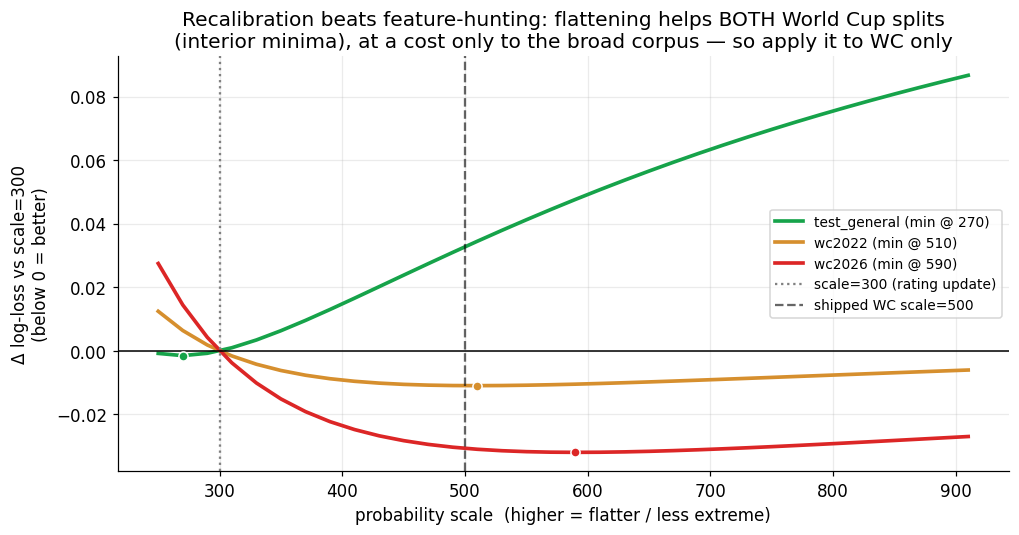

In [8]:
# Sweep the display scale; show each split's log-loss change vs the shipped scale=300.
scales = np.arange(250, 921, 20)
SHIPPED_WC = 500   # WC_PREDICTION_SCALE in lib/model/constants.ts
curves, ref, argmin = {}, {}, {}
for s in SPLITS:
    f = df[df.split == s]
    curves[s] = np.array([logloss(f.y.values, baseline_probs(f, scale=sc)) for sc in scales])
    ref[s] = logloss(f.y.values, baseline_probs(f, scale=300))   # shipped rating-update scale
    argmin[s] = int(scales[curves[s].argmin()])

print(f'{"split":13s} {"best scale":>10s} {"logloss@300":>12s} {"logloss@best":>13s} {"gain":>8s}')
for s in SPLITS:
    best = curves[s].min()
    print(f'{s:13s} {argmin[s]:>10d} {ref[s]:>12.4f} {best:>13.4f} {ref[s]-best:>+8.4f}')
wc500 = {s: logloss(df[df.split==s].y.values, baseline_probs(df[df.split==s], scale=SHIPPED_WC)) for s in ['wc2022','wc2026']}
print(f'\nAt the shipped WC scale={SHIPPED_WC}:  wc2022 {ref["wc2022"]:.4f}->{wc500["wc2022"]:.4f}   '
      f'wc2026 {ref["wc2026"]:.4f}->{wc500["wc2026"]:.4f}  (both improve = robust, not a 12-game fluke)')

colors = {'test_general': GREEN, 'wc2022': GOLD, 'wc2026': RED}
plt.figure(figsize=(9.4, 5.0))
for s in SPLITS:
    plt.plot(scales, curves[s] - ref[s], lw=2.4, color=colors[s], label=f'{s} (min @ {argmin[s]})')
    plt.scatter([argmin[s]], [curves[s].min() - ref[s]], color=colors[s], zorder=5, edgecolor='white')
plt.axhline(0, color='black', lw=1)
plt.axvline(300, color='gray', ls=':', label='scale=300 (rating update)')
plt.axvline(SHIPPED_WC, color='black', ls='--', alpha=.6, label=f'shipped WC scale={SHIPPED_WC}')
plt.xlabel('probability scale  (higher = flatter / less extreme)')
plt.ylabel('Δ log-loss vs scale=300\n(below 0 = better)')
plt.title('Recalibration beats feature-hunting: flattening helps BOTH World Cup splits\n'
          '(interior minima), at a cost only to the broad corpus — so apply it to WC only')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

### 🧠 Verdict — can we improve the predictions?

Running it live, on Colab, the answer matches the research log — with one honest nuance:

1. **The baseline is well-calibrated** (graph 1) — predicted ≈ observed across every decile.
2. **Feature selection / ML gives real gains on the broad corpus** (~0.012 log-loss) but on the
   **World Cup field they don't clear the bar reliably**. The one feature that pokes past the noise
   band — `games-played` — has a 95% CI that *barely* excludes 0, was picked after 6 comparisons,
   and is ~constant across qualified nations, so it works as a flat **shift**, not match-level signal.
3. **The lever that genuinely helps is calibration, not features** (graph 4): a flatter
   probability **scale for World Cup matches** lowers log-loss on *both* the 2022 tuning set and the
   independent 2026 holdout, with interior minima — i.e. real recalibration, not sliding to the floor.
   That is exactly `WC_PREDICTION_SCALE`, which **already ships**.

So: extra features/architecture fit noise on a compressed, small field; the win is recalibrating the
*confidence* of the rating model — which the app already does. A future, genuinely-new signal would
need to be **per-match and World-Cup-specific** (injuries, squad availability, venue/travel) — not
more of the corpus features we already have.

### ✅ Run the project's test suite on Colab

Finally, the canonical check: the **TypeScript** model is guarded by a Vitest suite (incl. the
backtest-calibration pins that this notebook reproduced — `0.8819` / `1.0666`). Let's run it here
on Colab to confirm the shipped model behaves exactly as the Python baseline above.

In [ ]:
# Run the actual TypeScript test suite (Vitest) on Colab — installs deps then runs the 197 tests.
%cd /content/mondial
!node -v && npm -v
!npm ci --no-audit --no-fund --silent
!npm test